<center><h1>Last_First_HW2</h1></center>
<br>
<br>

**Name**: Lohit Nambiar
<br>
Github Username: lnambiar18
<br>
USC ID: 8395177707

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [1]:
import zipfile
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.stats import linregress
import statsmodels.api as sm
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
import numpy as np

Get the Cycle Power Plant Data Set

In [2]:
with zipfile.ZipFile("CCPP.zip", "r") as zip_ref:
    zip_ref.extractall("CCPP")
data = pd.read_excel("CCPP/Folds5x2_pp.xlsx")
data.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


### (b) Exploring the data

#### i. rows and columns

In [3]:
rows = data.shape[0]
columns = data.shape[1]
print(f"The data has {rows} rows and {columns} columns.")

The data has 9568 rows and 5 columns.


The rows represent the data points and the columns represent the features being Temperature (T), Ambient Pressure (AP), Relative Humidity (RH), Exhaust Vacuum (V), and the target variable Electrical Energy Output (PE).

#### ii. pairwise scatterplots of all the varianbles

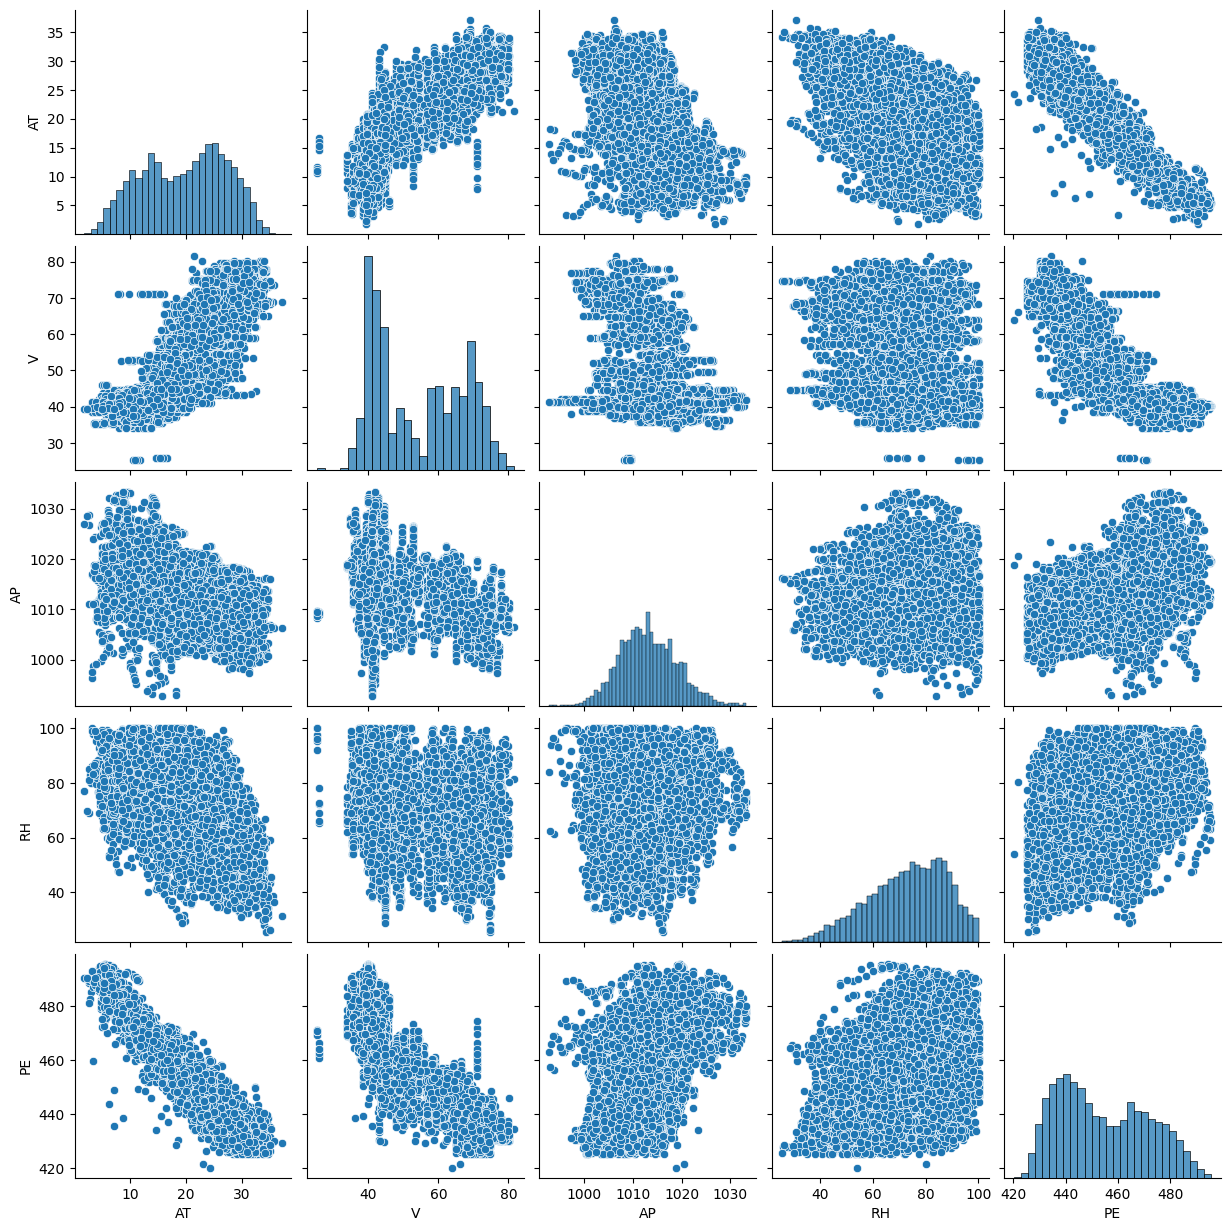

In [4]:
sn.pairplot(data)
plt.show()

The plots show that PE has a strong negative relationship with AT and V, meaning that power output usually decreases as temperature and exhaust vacuum increase. AP and RH seem to have weaker positive relationships with PE. There are also relationships between the predictors, especially the strong positive relationship between AT and V.

#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [5]:
stats = pd.DataFrame({"Mean": data.mean(), "Median": data.median(), "Range": data.max() - data.min(), "First Quartile": data.quantile(0.25), "Third Quartile": data.quantile(0.75),"Interquartile Range": (data.quantile(0.75) - data.quantile(0.25))})
stats

,Mean,Median,Range,First Quartile,Third Quartile,Interquartile Range
AT,19.651231,20.345,35.30,13.5100,25.72,12.2100
V,54.305804,52.080,56.20,41.7400,66.54,24.8000
AP,1013.259078,1012.940,40.41,1009.1000,1017.26,8.1600
RH,73.308978,74.975,74.60,63.3275,84.83,21.5025
PE,454.365009,451.550,75.50,439.7500,468.43,28.6800


### (c) Simple Linear Regression

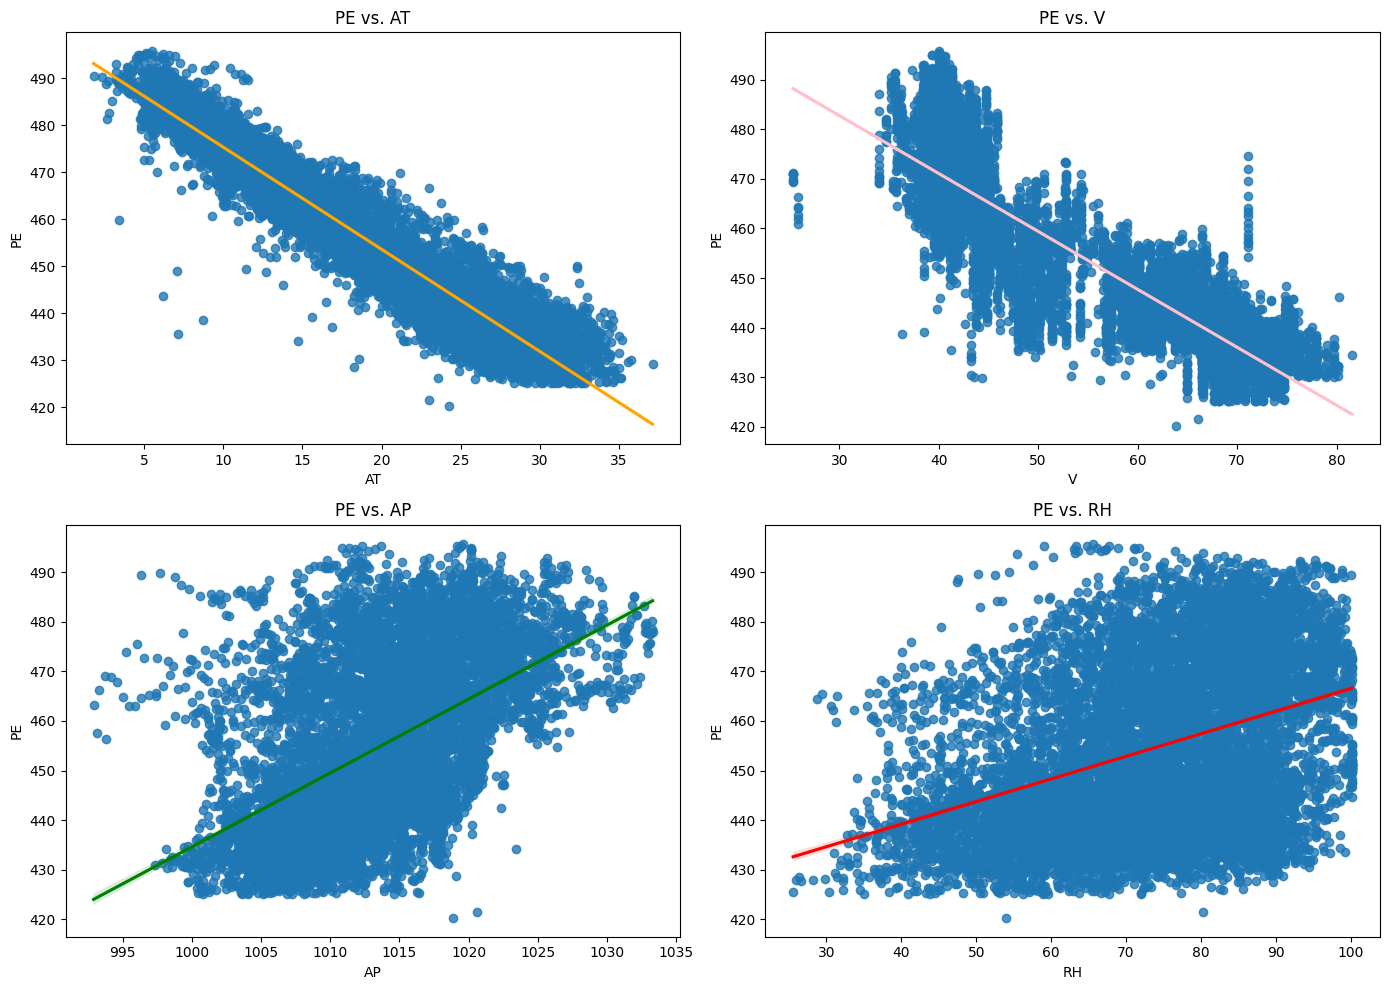

In [6]:
predictors = ["AT", "V", "AP", "RH"]
regression_results = []

for predictor in predictors:

    X = data[[predictor]]
    y = data["PE"]

    model = LinearRegression()
    model.fit(X, y)

    sig_test = linregress(data[predictor], data["PE"])

    regression_results.append({"Predictor": predictor, "Intercept": model.intercept_, "Coefficient": model.coef_[0], "R-squared": model.score(X, y), "P-value": sig_test.pvalue})

results_table = pd.DataFrame(regression_results)
results_table["Statistically Significant"] = (results_table["P-value"] < 0.05)
results_table

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sn.regplot(data=data, x="AT", y="PE",line_kws={"color": "orange"}, ax=axes[0][0])
axes[0][0].set_title("PE vs. AT")
sn.regplot(data=data, x="V", y="PE",line_kws={"color": "pink"}, ax=axes[0][1])
axes[0][1].set_title("PE vs. V")
sn.regplot(data=data, x="AP", y="PE", line_kws={"color": "green"}, ax=axes[1][0])
axes[1][0].set_title("PE vs. AP")
sn.regplot(data=data, x="RH", y="PE", line_kws={"color": "red"}, ax=axes[1][1])
axes[1][1].set_title("PE vs. RH")
plt.tight_layout()
plt.show()

All four predictors have a statistically significant association with PE since each of their p-values is less than 0.005. AT and V have strong negative relationships with PE, while AP and RH have weaker positive relationships. The plots show that AT follows a fairly clear linear pattern, while the other predictors have more spread and may not be perfectly linear. There are some outliers, mainly in the AT and V plots, but I would not remove them without knowing whether they are actually data errors.

### (d) Multiple Regression

In [7]:
predictors = ["AT", "V", "AP", "RH"]

X = data[predictors]
y = data["PE"]

multiple_model = LinearRegression()
multiple_model.fit(X, y)

y_pred = multiple_model.predict(X)


X = sm.add_constant(X)
multiple_model = sm.OLS(y, X).fit()
multiple_results = pd.DataFrame({"Coefficient": multiple_model.params, "Standard Error": multiple_model.bse, "t-statistic": multiple_model.tvalues, "P-value": multiple_model.pvalues})
multiple_results["Reject H0"] = (multiple_results["P-value"] < 0.05)
multiple_results

,Coefficient,Standard Error,t-statistic,P-value,Reject H0
const,454.609274,9.748512,46.633709,0.000000e+00,True
AT,-1.977513,0.015289,-129.342024,0.000000e+00,True
V,-0.233916,0.007282,-32.122109,4.375305e-215,True
AP,0.062083,0.009458,6.564086,5.507109e-11,True
RH,-0.158054,0.004168,-37.918473,3.104584e-293,True


The results show that AT, V, and RH have negative relationships with PE when the other predictors are held constant, while AP has a positive relationship. All four predictors have p-values below 0.05, so we can reject the null hypothesis that their coefficients are equal to zero. This means that AT, V, AP, and RH are all statistically significant predictors of PE in the multiple regression model.

### (e) 1c Compare to 1d

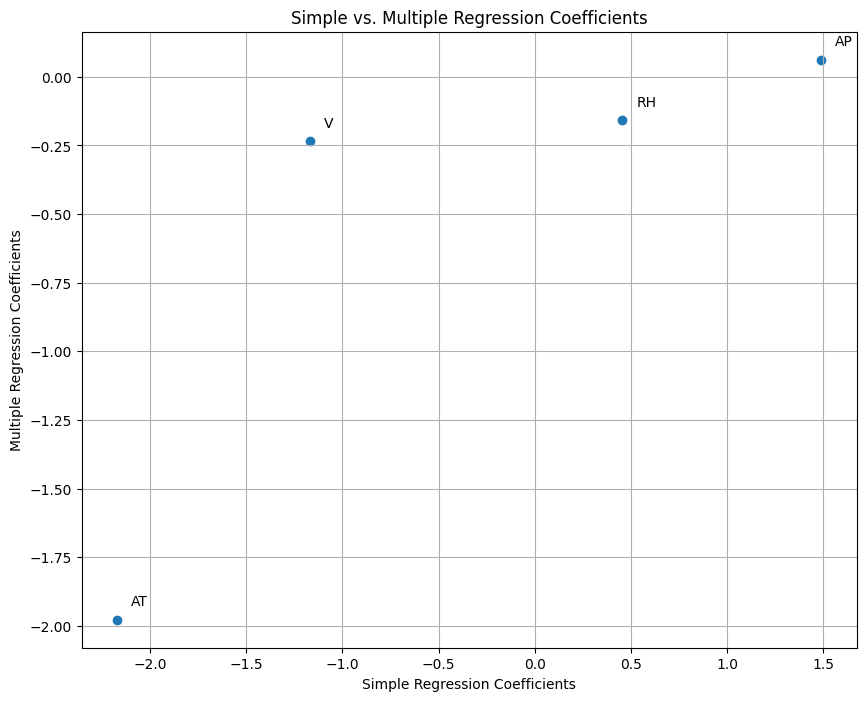

In [8]:
simple_coefficients = results_table["Coefficient"].values
multiple_coefficients = multiple_model.params[predictors].values

plt.figure(figsize=(10, 8))

plt.scatter(simple_coefficients, multiple_coefficients)

for i in range(len(predictors)):
    plt.annotate(predictors[i],(simple_coefficients[i], multiple_coefficients[i]), xytext=(10, 10), textcoords="offset points")

plt.xlabel("Simple Regression Coefficients")
plt.ylabel("Multiple Regression Coefficients")
plt.title("Simple vs. Multiple Regression Coefficients")
plt.grid(True)
plt.show()

AT has a similar negative coefficient in both models, while the coefficients for V and AP become much smaller in the multiple regression model. RH changes from a positive coefficient in the simple regression to a negative coefficient in the multiple regression.

### (f) Nonlinear Association

In [9]:
predictors = ["AT", "V", "AP", "RH"]

poly_results = []

for predictor in predictors:

    X = data[[predictor]]
    poly = PolynomialFeatures(degree=3, include_bias=False)
    X_poly = poly.fit_transform(X)

    X_poly = pd.DataFrame(X_poly, columns=["X", "X^2", "X^3"])
    X_poly = sm.add_constant(X_poly)

    model = sm.OLS(data["PE"].reset_index(drop=True), X_poly).fit()

    poly_results.append({"Predictor": predictor, "X P-value": model.pvalues["X"], "X^2 P-value": model.pvalues["X^2"], "X^3 P-value": model.pvalues["X^3"], "R-squared": model.rsquared})

poly_results = pd.DataFrame(poly_results)
poly_results["Nonlinear association?"] = ((poly_results["X^2 P-value"] < 0.05) | (poly_results["X^3 P-value"] < 0.05))
poly_results

/tmp/ipykernel_2844/3665221543.py:14: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model = sm.OLS(data["PE"].reset_index(drop=True), X_poly).fit()


,Predictor,X P-value,X^2 P-value,X^3 P-value,R-squared,Nonlinear association?
0,AT,7.898147e-07,8.833045e-73,3.652185e-110,0.911883,True
1,V,2.526589e-05,7.684969e-01,1.373489e-02,0.775022,True
2,AP,4.502735e-17,3.666705e-17,8.264146e-18,0.274863,True
3,RH,3.772510e-04,9.395430e-06,1.440279e-05,0.153743,True


There is evidence of a nonlinear association between all four predictors and PE because each model has at least one significant quadratic or cubic term with a p-value below 0.05. AT shows the strongest nonlinear relationship with an R-squared of about 0.91, followed by V with an R-squared of about 0.77.


### (g) Interactions of Predictors

In [10]:
predictors = ["AT", "V", "AP", "RH"]

X = data[predictors]
y = data["PE"]

interaction_gen = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)

X_interactions = interaction_gen.fit_transform(X)

interaction_names = interaction_gen.get_feature_names_out(predictors)

X_interactions = pd.DataFrame(X_interactions, columns=interaction_names, index=data.index)
X_interactions = sm.add_constant(X_interactions)

interaction_model = sm.OLS(y, X_interactions).fit()

interaction_terms = [
    "AT V",
    "AT AP",
    "AT RH",
    "V AP",
    "V RH",
    "AP RH"
]

interaction_results = pd.DataFrame({"Coefficient": interaction_model.params[interaction_terms], "P-value": interaction_model.pvalues[interaction_terms]})
interaction_results["Statistically Sign"] = (interaction_results["P-value"] < 0.05)

interaction_results

,Coefficient,P-value,Statistically Sign
AT V,0.020971,3.333358e-117,True
AT AP,0.001759,4.520509e-01,False
AT RH,-0.005230,1.216944e-10,True
V AP,0.006812,2.877026e-07,True
V RH,0.000839,8.619366e-02,False
AP RH,-0.001612,3.360557e-02,True


There is evidence that some interactions between the predictors are associated with PE. The AT–V, AT–RH, V–AP, and AP–RH interaction terms are statistically significant because their p-values are below 0.05, while AT–AP and V–RH are not significant.

### (h) Improvement

In [11]:
predictors = ["AT", "V", "AP", "RH"]

X = data[predictors]
y = data["PE"]

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.70, random_state=1018)

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_train_predictions = linear_model.predict(X_train)
linear_test_predictions = linear_model.predict(X_test)
linear_train_mse = mean_squared_error(y_train,linear_train_predictions)
linear_test_mse = mean_squared_error(y_test,linear_test_predictions)

print("Linear regression train MSE:", linear_train_mse)
print("Linear regression test MSE:", linear_test_mse)

polynomial = PolynomialFeatures(degree=2, include_bias=False)

X_train_polynomial = polynomial.fit_transform(X_train)
X_test_polynomial = polynomial.transform(X_test)

polynomial_names = polynomial.get_feature_names_out(predictors)

X_train_polynomial = pd.DataFrame(X_train_polynomial, columns=polynomial_names, index = X_train.index)
X_test_polynomial = pd.DataFrame(X_test_polynomial,columns=polynomial_names, index = X_test.index)

selected_terms = list(polynomial_names)

while True:
    X_current = sm.add_constant(X_train_polynomial[selected_terms])

    polynomial_model = sm.OLS(y_train, X_current).fit()

    p_values = polynomial_model.pvalues.drop("const")

    removable_terms = []

    for term in selected_terms:
        if p_values[term] > 0.05:
            can_remove = True
            if term in predictors:
                for other_term in selected_terms:
                    if other_term == term + "^2":
                        can_remove = False
                    if " " in other_term:
                        variables = other_term.split(" ")
                        if term in variables:
                            can_remove = False

            if can_remove:
                removable_terms.append(term)
    if len(removable_terms) == 0:
        break
    term_to_remove = removable_terms[0]

    for term in removable_terms:
        if p_values[term] > p_values[term_to_remove]:
            term_to_remove = term

    print("Getting rid of", term_to_remove, "with p-value", p_values[term_to_remove])
    selected_terms.remove(term_to_remove)

    final_poly_results = pd.DataFrame({"Coefficient": polynomial_model.params, "P-value": polynomial_model.pvalues})

X_train_selected = sm.add_constant(X_train_polynomial[selected_terms])
X_test_selected = sm.add_constant(X_test_polynomial[selected_terms])
polynomial_train_predictions = polynomial_model.predict(X_train_selected)
polynomial_test_predictions = polynomial_model.predict(X_test_selected)
polynomial_train_mse = mean_squared_error(y_train, polynomial_train_predictions)
polynomial_test_mse = mean_squared_error(y_test, polynomial_test_predictions)
print("Polynomial regression train MSE:", polynomial_train_mse)
print("Polynomial regression test MSE:", polynomial_test_mse)

mse_results = pd.DataFrame({"Model": ["Linear Regression", "Polynomial and Interaction Regression"], "Train MSE": [linear_train_mse, polynomial_train_mse], "Test MSE": [linear_test_mse, polynomial_test_mse]})

mse_results

Linear regression train MSE: 20.982330720877865
Linear regression test MSE: 20.279688430555538
Getting rid of V AP with p-value 0.6446259183839678
Getting rid of V RH with p-value 0.11846443898827216
Getting rid of V^2 with p-value 0.24848590081516259
Polynomial regression train MSE: 18.11520303983035
Polynomial regression test MSE: 18.144634931415535


,Model,Train MSE,Test MSE
0,Linear Regression,20.982331,20.279688
1,Polynomial and Interaction Regression,18.115203,18.144635


### (i) KNN

In [ ]:
k_values = list(range(1, 101))

raw_train_errors = []
raw_test_errors = []

for k in k_values:
    knn_raw = KNeighborsRegressor(n_neighbors=k)

    knn_raw.fit(X_train, y_train)

    raw_train_predictions = knn_raw.predict(X_train)
    raw_test_predictions = knn_raw.predict(X_test)

    raw_train_mse = mean_squared_error(y_train, raw_train_predictions)
    raw_test_mse = mean_squared_error(y_test, raw_test_predictions)

    raw_train_errors.append(raw_train_mse)
    raw_test_errors.append(raw_test_mse)

best_raw_error = min(raw_test_errors)
best_raw_index = raw_test_errors.index(best_raw_error)
best_raw_k = k_values[best_raw_index]

print("Best k for raw features:", best_raw_k)
print("Best raw test MSE:", best_raw_error)

scaler = StandardScaler()
X_train_normalized = scaler.fit_transform(X_train)
X_test_normalized = scaler.transform(X_test)

normalized_train_errors = []
normalized_test_errors = []

for k in k_values:
    knn_normalized = KNeighborsRegressor(n_neighbors=k)
    knn_normalized.fit(X_train_normalized, y_train)

    normalized_train_predictions = (knn_normalized.predict(X_train_normalized))
    normalized_test_predictions = (knn_normalized.predict(X_test_normalized))

    normalized_train_mse = mean_squared_error(y_train, normalized_train_predictions)
    normalized_test_mse = mean_squared_error(y_test, normalized_test_predictions)

    normalized_train_errors.append(normalized_train_mse)
    normalized_test_errors.append(normalized_test_mse)

best_normalized_error = min(normalized_test_errors)
best_normalized_index = normalized_test_errors.index(best_normalized_error)
best_normalized_k = k_values[best_normalized_index]
print("Best k for normalized features:", best_normalized_k)
print("Best normalized test MSE:", best_normalized_error)

inver_k = [1 / k for k in k_values]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].plot(inver_k, raw_train_errors, label="Train MSE")
axes[0].plot(inver_k, raw_test_errors, label="Test MSE")
axes[0].set_title("KNN Regression With Raw Features")
axes[0].set_xlabel("1/k")
axes[0].set_ylabel("Mean Squared Error")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(inver_k, normalized_train_errors, label="Train MSE")
axes[1].plot(inver_k, normalized_test_errors, label="Test MSE")
axes[1].set_title("KNN Regression With Normalized Features")
axes[1].set_xlabel("1/k")
axes[1].set_ylabel("Mean Squared Error")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

knn_results = pd.DataFrame({"Feature": ["Raw", "Normalized"], "Best k": [best_raw_k, best_normalized_k],"Best Test MSE": [best_raw_error, best_normalized_error]})
knn_results

### (j ) Compare KNN and Linear

In [ ]:
regression_test_errors = {"Multiple Linear Regression": linear_test_mse, "Polynomial and Interaction Regression": polynomial_test_mse}
best_regression_model = min(regression_test_errors, key=regression_test_errors.get)
best_regression_test_mse = regression_test_errors[best_regression_model]

if best_regression_model == "Multiple Linear Regression":
    best_regression_train_mse = linear_train_mse
else:
    best_regression_train_mse = polynomial_train_mse

if best_raw_error < best_normalized_error:
    best_knn_model = "KNN With Raw Features"
    best_knn_k = best_raw_k
    best_knn_test_mse = best_raw_error
    best_knn_train_mse = raw_train_errors[best_raw_index]
else:
    best_knn_model = "KNN With Normalized Features"
    best_knn_k = best_normalized_k
    best_knn_test_mse = best_normalized_error
    best_knn_train_mse = normalized_train_errors[best_normalized_index]


comparison_results = pd.DataFrame({"Model": [best_regression_model, best_knn_model], "Best k": ["No k for this one", best_knn_k], "Train MSE": [best_regression_train_mse, best_knn_train_mse], "Test MSE": [best_regression_test_mse, best_knn_test_mse]})

comparison_results

The KNN model with normalized features and with a k = 5 performed better because its test MSE of 15.21 was lower than the polynomial and interaction regression model’s test MSE of 18.14. KNN also had a much lower training MSE, showing that it was able to capture more of the nonlinear patterns in the data. However, the larger difference between its training and test MSE showed that their could be some overfitting happeing though. Overall, KNN gave the better test performance.

## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

A flexible model would perfrom better because the large sample size gives it enough data to learn more hard patterns without overfitting. Since the number of predictors is small, the model also does not have to estimate too many relationships that could be there.

### (b) The number of predictors p is extremely large, and the number of observations n is small.

A flexible method would most likely perform worse because there are too many predictors but not enough observations/data to support them. This makes it much easier for the model to overfit the training data and thus perform badly on unseen data.

### (c) The relationship between the predictors and response is highly non-linear.

A flexible method would perform better because it can capture the highly nonlinear relationship between the predictors and response.

### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.

A flexible method would most likely perform worse because the high error variance means there is a lot of  noise in the data. A flexible method may end up learning noise rather than the actual patterns, leading to poor performance.

## 3. ISLR: 2.4.7

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

In [ ]:
observations = np.array([[0, 3, 0], [2, 0, 0], [0, 1, 3], [0, 1, 2], [-1, 0, 1], [1, 1, 1]])

test_point = np.array([0, 0, 0])
for i in range(len(observations)):
    distance = np.sqrt(np.sum((observations[i] - test_point) ** 2))

    print("Observation", i + 1, "distance:", distance)

### (b) What is our prediction with K = 1? Why?

When K = 1, we need to use the observation with the smallest distance to the test point (0,0,0), in that case the observation is observation 5, which has a class of Green, so when K = 1, we predict Green also.

### (c) What is our prediction with K = 3? Why?

When K = 3, we need to look at the three smallest observartion distances, that being observation 2, 5, and 6. Since Observations 2 and 6 are red and KNN is majoirty based, when K = 3, our prediction will also be red.

### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

We would expect the best value for K to be small because a small K allows for more flexibilty to conform to the non-linear boundary, while a high K is less flexible.